# IM-GDHP on F16: removing step-tracking offsets

This complete example uses the **TensorAeroSpace SDK** with **alpha as the only commanded quantity**. Pitch rate `q` is recorded for diagnosis; it is not a policy input or a second tracking objective. The step changes from **0° to 1° at 20 s**. The primary assessment retains its **38-second horizon**, and additional 60-second assessments distinguish a decaying transient from a persistent offset.

The actor and scalar critic retain the losses in [Sun and van Kampen (2021)](https://doi.org/10.1016/j.asoc.2021.107153), Eqs. (51)–(67). This example explicitly uses a **known-reference extension**: RLS identifies measured aircraft outputs and the learning target subtracts the known next reference. The default SDK mode still identifies error dynamics as in the article. A discontinuous command is therefore not mistaken for aircraft dynamics in this example.

The previous configuration retained a trim command learned at alpha=1° and adapted it too slowly. Here a reproducible second training stage adjusts the actor's input scaling and learning rate, then includes a zero-command episode. **Every subsequent assessment keeps actor, critic and RLS adaptation enabled.** Parameters are not switched at the command time, and no PID or integral controller is added.

The closed-loop model is the **linear longitudinal F16**. The nonlinear section separately tests identification; it does not establish nonlinear flight-control performance. Long holds accumulate pitch and are numerical stress tests of the fixed linearization. Numerical accuracy in these experiments is not a proof of global stability.

**Recomputed result, seed 0:** zero-hold maximum error **0.000120°**, 38-second tail mean error **+0.000212°**, command overshoot **4.50%**, command-band settling **3.38 s**, **CPI 0.9237**. All 12 seed/amplitude assessments pass the final-five-second 0.1%-accuracy condition at 60 s. The command sequence retains larger finite-time residuals: its largest final-five-second mean magnitude is about 0.00192°. These are measured finite-horizon errors, not a claim of mathematically exact zero error for every signal.


In [1]:
from dataclasses import replace
import copy
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

import tensoraerospace  # registers the Gymnasium environments
from tensoraerospace.agent.im_gdhp import IMGDHPAgent, IMGDHPConfig, IncrementalModelRLS

torch.set_num_threads(1)
np.random.seed(0)
torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
from tensoraerospace.benchmark import ControlBenchmark

## 1. One reference: angle of attack

The environment returns `[alpha, q]` in radians and radians/second; elevator commands are in degrees. `tracking_states=["alpha"]`, `tracking_indices=[0]` and `reference_size=1` keep the reference array at shape `(1, T)`.

The first training stage uses 12-second constant-1° episodes. Evaluation is separate: the command remains zero until **20 s**, then becomes 1°. The **38 s** primary run preserves the previous 18-second post-step window. Neither the zero-command hold nor failed assessments are removed from the results.


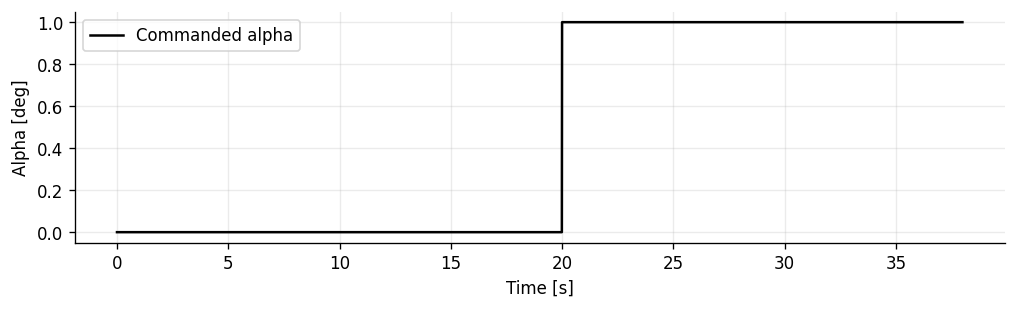

In [2]:
DT = 0.01
N = 1200
STEP_TIME = 20.0
STEP_AMPLITUDE_DEG = 1.0
POST_STEP_DURATION = 18.0
EVALUATION_DURATION = STEP_TIME + POST_STEP_DURATION
TIME = np.arange(N) * DT

def step_reference(samples, amplitude_deg=STEP_AMPLITUDE_DEG):
    time = np.arange(samples) * DT
    alpha = np.deg2rad(np.where(time >= STEP_TIME, amplitude_deg, 0.0))
    return alpha[None, :]

REFERENCE = np.full((1, N), np.deg2rad(STEP_AMPLITUDE_DEG))
EVALUATION_REFERENCE = step_reference(round(EVALUATION_DURATION / DT))

def make_env(reference):
    return gym.make(
        "LinearLongitudinalF16-v0",
        initial_state=np.zeros(4),
        reference_signal=reference,
        tracking_states=["alpha"], state_space=["alpha", "q"],
        number_time_steps=reference.shape[1],
    ).unwrapped

plt.figure(figsize=(10, 2.5))
plt.plot(np.arange(EVALUATION_REFERENCE.shape[1]) * DT, np.rad2deg(EVALUATION_REFERENCE[0]), color="black", label="Commanded alpha")
plt.xlabel("Time [s]")
plt.ylabel("Alpha [deg]")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 2. Warm-start configuration

The networks receive only `alpha - alpha_ref`. `obs_scale` converts their input to degrees; the model and critic derivative retain physical coordinates. Tracking cost is `200 * alpha_error_rad**2`; control cost is zero. The diagonal RLS prior accounts for the different units of alpha increments and elevator increments.

The following configuration reproduces the earlier 30-episode warm start. It is **not the final deployment configuration**. Section 4 applies the same sensitivity-based tuning procedure to every seed, then trains on zero reference. No earlier checkpoint is restored.

`beta_lambda` is the derivative/scalar loss ratio, with paper beta `1/(1+beta_lambda)`. Its small value is near the HDP limit of Eq. (59). The 100 Hz sample rate, scaling, gradient clipping, warmup and tuning protocol differ from the article's experiment; this notebook is not a reproduction of its plots.


In [3]:
scale = 180 / np.pi
actor_bias = 0.46
covariance_diagonal = (1e4 * np.full(4, scale)**2).tolist() + [1e4] * 4
cfg = IMGDHPConfig(
    actor_hidden=(16,), critic_hidden=(16,), actor_bias_input=actor_bias,
    actor_lr=2.0 / actor_bias**2, critic_lr=0.01,
    actor_lr_decay=0.99995, critic_lr_decay=0.9997,
    actor_lr_min=1e-5, critic_lr_min=1e-5,
    track_Q=(200 / scale**2,), control_R=(0.0,), beta_lambda=0.001 / scale**2,
    history_length=4, obs_scale=(scale, scale), gamma=0.9,
    warmup_steps=2000, critic_only_steps=1000, max_grad_norm=5.0,
    cov_init=covariance_diagonal, forgetting=0.999, u_max=3.0, seed=0,
)
agent = IMGDHPAgent(
    n_obs=2, n_action=1, reference_size=1, tracking_indices=[0], config=copy.deepcopy(cfg)
)


## 3. Complete SDK interaction and metrics

`predict → env.step → learn` is the online interaction. `learn` evaluates the old incremental model and then assimilates the new measurement, avoiding target leakage. `reset` clears episode history while retaining learned parameters. The function below only runs an experiment and measures it; the controller and aircraft equations are provided by the library.

Compare the observation **after** a step to the reference at `k+1`. The envelope check terminates an invalid run rather than treating a partial trajectory as a good result.

In [4]:
def run_episode(agent, reference, *, learning, noise=0.0):
    env = make_env(reference)
    obs, _ = env.reset()
    agent.reset()
    agent.cfg.exploration_noise_std = noise
    observations, commands = [], []
    try:
        for k in range(reference.shape[1] - 1):
            action = agent.predict(
                np.asarray(obs).ravel(), reference, k, deterministic=noise == 0
            )
            obs, _, terminated, truncated, _ = env.step(action)
            if not np.isfinite(obs).all() or abs(
                float(np.asarray(obs).ravel()[0])
            ) > np.deg2rad(25):
                raise RuntimeError(f"alpha envelope exceeded at step {k}")
            if learning:
                updates = agent.learn(np.asarray(obs).ravel(), reference, k)
                if k > 0 and agent._total_steps > agent.cfg.warmup_steps + agent.cfg.critic_only_steps + 1:
                    if not all(np.isfinite(updates[key]) for key in ("actor_loss", "critic_loss")):
                        raise RuntimeError(f"Nonfinite network loss at step {k}")
            observations.append(np.asarray(obs).ravel().copy())
            commands.append(action.copy())
            if terminated or truncated:
                break
        peak_theta_deg = float(np.max(np.abs(np.rad2deg(
            env.model.store_states[0, :env.model.time_step + 1]
        ))))
    finally:
        env.close()
    y, u = np.asarray(observations), np.asarray(commands)
    err = np.rad2deg(y[:, 0] - reference[0, 1 : len(y) + 1])
    return (
        {
            "rmse_deg": float(np.sqrt(np.mean(err**2))),
            "mae_deg": float(np.mean(np.abs(err))),
            "peak_alpha_deg": float(np.max(np.abs(np.rad2deg(y[:, 0])))),
            "peak_rate_deg_s": float(np.max(np.abs(np.rad2deg(y[:, 1])))),
            "peak_command_deg": float(np.max(np.abs(u))),
            "saturation_fraction": float(np.mean(np.abs(u) >= 0.99 * agent.cfg.u_max)),
            "samples": len(y),
            "peak_theta_deg": peak_theta_deg,
        },
        y,
        u,
    )



## 4. Warm start and online sensitivity tuning

First train **30 episodes** with elevator exploration noise sigma=0.1°. Then tune the local feedback sensitivity to **0.25 deg of elevator per deg of alpha error**. `retune_actor_inputs` changes the first-layer error weights and rescales the constant actor input to 30; changing that constant preserves the zero-error action at the moment of retuning. Its scale sets how readily later SGD updates can change trim. The critic and identifier are retained.

Choose the online learning rate from the small-error form of the **existing Eq. (67)**. With `g0` the identified immediate input gain, `lambda0` the critic derivative at zero and `a = du/dw`, the local action-change sensitivity per second is approximately

$$
k_{adapt} = \frac{\eta_a\,\lambda_0^2 |g_0|\,\|a\|^2}{(180/\pi)\,dt}.
$$

Set this sensitivity to **0.03 deg/(deg·s)**. This is a hyperparameter-selection rule for the published actor loss, not a new feedback term. It avoids assigning the same effective adaptation speed to differently scaled trained networks. The procedure uses current network/model derivatives; it does not use evaluation step times or amplitudes.

Finally perform **60 seconds of additional zero-reference training** to remove the trim inherited from the constant-1° task. This is an explicit training episode, not a hidden warmup removed from the evaluation plot. After it, independent evaluations reset the aircraft and history while retaining all learned parameters. The actor learning rate is positive and constant online; the critic continues at its positive lower bound.

The default unknown-reference mode from the paper remains available. For these known commands, the agent switches to `identifier_mode="output"` after clearing history. Model parameters from constant-reference training are reusable because output increments and error increments are identical when the reference is constant.


Warm-start episode 10: RMSE=0.41933 deg


Warm-start episode 20: RMSE=0.29476 deg


Warm-start episode 30: RMSE=0.27876 deg


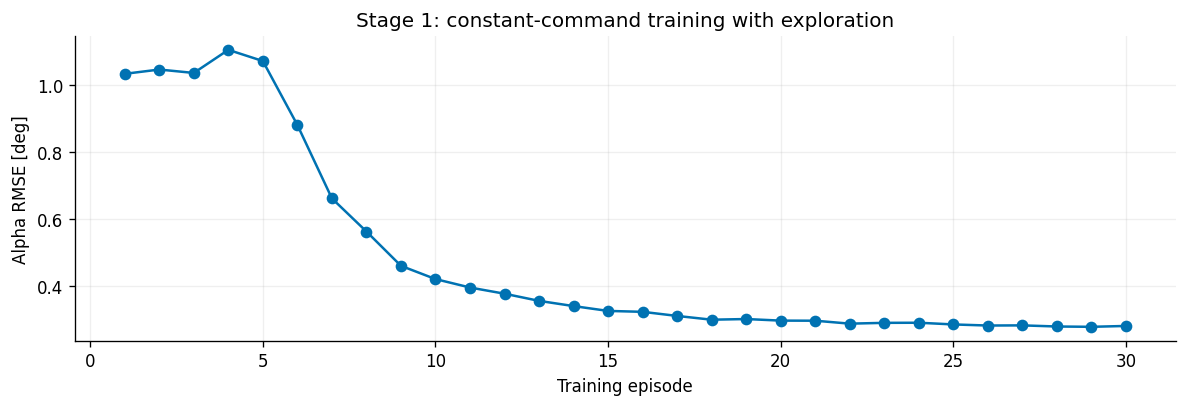

,Stage 2 configuration
Feedback gain multiplier,0.635616
Actor bias input,30.000000
Online actor learning rate,0.019916
Identified input gain,-0.000001
Critic derivative at zero,-24.125891
Zero-training RMSE [deg],0.045141


Final actor learning rate: 0.019916313603912175
Final critic learning rate: 1e-05


In [5]:
benchmark = ControlBenchmark()

def step_metrics(reference, observation):
    metrics = benchmark.benchmarking_step_response(
        control_signal=reference[0, 1:len(observation) + 1],
        system_signal=observation[:, 0], signal_val=0.0, dt=DT,
    )
    tail = max(1, int(0.1 * len(observation)))
    error = reference[0, 1:len(observation) + 1] - observation[:, 0].astype(float)
    metrics["tail_static_error"] = float(np.mean(error[-tail:]))
    metrics["tail_peak_to_peak"] = float(np.ptp(observation[-tail:, 0].astype(float)))
    return metrics

NUM_EPISODES = 30
training_rmse = []
for ep in range(NUM_EPISODES):
    train_metrics, _, _ = run_episode(agent, REFERENCE, learning=True, noise=0.1)
    training_rmse.append(train_metrics["rmse_deg"])
    if (ep + 1) % 10 == 0:
        print(f"Warm-start episode {ep + 1}: RMSE={training_rmse[-1]:.5f} deg")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(np.arange(1, NUM_EPISODES + 1), training_rmse, "o-", color="#0072B2")
ax.set(xlabel="Training episode", ylabel="Alpha RMSE [deg]",
       title="Stage 1: constant-command training with exploration")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

FEEDBACK_SENSITIVITY = 0.25
ADAPTATION_SENSITIVITY = 0.03
ONLINE_BIAS_INPUT = 30.0
ZERO_TRAINING_DURATION = 60.0

def prepare_online_learning(trial):
    """Configure a trained SDK agent, then complete its zero-reference training."""
    trial.reset()
    trial.cfg.identifier_mode = "output"
    zero_error = torch.zeros(1, device=trial.device)
    feedback_slope = float(torch.autograd.functional.jacobian(
        trial.actor, zero_error).item()) / scale
    if feedback_slope <= 0:
        raise ValueError("Warm start has the wrong local feedback sign for this F16")
    feedback_gain = FEEDBACK_SENSITIVITY / feedback_slope
    trial.retune_actor_inputs(feedback_gain=feedback_gain, bias_input=ONLINE_BIAS_INPUT)
    action = trial.actor(zero_error)
    gradients = torch.autograd.grad(action.sum(), tuple(trial.actor.parameters()))
    action_gradient_squared = sum(float(gradient.square().sum()) for gradient in gradients)
    lambda_zero = float(trial.critic(zero_error)[1].item())
    input_gain = float(trial.incremental_model.B[0, 0])
    if input_gain >= 0 or abs(lambda_zero) < 1e-8 or action_gradient_squared <= 0:
        raise ValueError("Warm start has insufficient or inconsistent local sensitivities")
    actor_rate = (ADAPTATION_SENSITIVITY * DT * scale
                  / (lambda_zero**2 * abs(input_gain) * action_gradient_squared))
    if not np.isfinite(actor_rate) or actor_rate < trial.cfg.actor_lr_min:
        raise ValueError("Derived actor rate is outside the configured learning range")
    trial.cfg.actor_lr = actor_rate
    trial.cfg.actor_lr_decay = 1.0
    for group in trial.actor_opt.param_groups:
        group["lr"] = actor_rate
    zero_reference = np.zeros((1, round(ZERO_TRAINING_DURATION / DT)))
    zero_metrics, _, _ = run_episode(trial, zero_reference, learning=True)
    return {"Feedback gain multiplier": feedback_gain, "Actor bias input": ONLINE_BIAS_INPUT,
            "Online actor learning rate": actor_rate, "Identified input gain": input_gain,
            "Critic derivative at zero": lambda_zero,
            "Zero-training RMSE [deg]": zero_metrics["rmse_deg"]}

online_tuning = prepare_online_learning(agent)
display(pd.Series(online_tuning, name="Stage 2 configuration").to_frame())
print("Final actor learning rate:", agent.actor_opt.param_groups[0]["lr"])
print("Final critic learning rate:", agent.critic_opt.param_groups[0]["lr"])


## 5. Step response with ControlBenchmark

The primary experiment applies a **1° step at 20 s**, lasts **38 s** and retains **online learning throughout**. The SDK `ControlBenchmark.benchmarking_step_response` evaluates the portion after the command, in radians with dt=0.01 s. **Lower CPI is better under an identical protocol.**

Every independent rollout starts from a copy of the fully trained agent, including optimizer and identifier state. The main trained instance is preserved. The sequence test later intentionally uses one continuously adapting copy across all commands, with no resets between plateaus.

### 5.1. Run the primary step


In [6]:
online_metrics, y, u = run_episode(
    copy.deepcopy(agent), EVALUATION_REFERENCE, learning=True
)
online_step = step_metrics(EVALUATION_REFERENCE, y)
print(f"Step: 0 → {STEP_AMPLITUDE_DEG:g} deg at t={STEP_TIME:g} s")
print(f"Experiment: {EVALUATION_DURATION:g} s; dt={DT:g} s; adaptation ON")
print(f"Composite performance index: {online_step['performance_index']:.6f} (lower is better)")


Step: 0 → 1 deg at t=20 s
Experiment: 38 s; dt=0.01 s; adaptation ON
Composite performance index: 0.923675 (lower is better)


### 5.2. Transient metrics and total tracking error

**Command-relative settling** requires staying within ±5% of the requested step until the end of the experiment. `Not reached` means this did not happen; it is not zero settling time.

The benchmark's existing rise time, conventional settling time and overshoot use the **final measured response**. Their labels below distinguish them from command-relative metrics. In particular, settling near an incorrect final angle is not successful command tracking.

IAE is the total absolute tracking error integrated over the post-step interval; ISE penalizes squared error and ITAE gives more weight to late error. CPI is taken directly from the library. Degree conversion is used only for display, not to recompute CPI.

The explicit accuracy condition uses the final-10% mean error. Both it and the original benchmark static error are shown below. The initial zero-command hold is checked separately; passing the post-step checks alone does not establish tracking of the complete reference.


In [7]:
metric_rows = [
    ("Composite performance index ↓", "library score", "performance_index", 1.0),
    ("Overshoot relative to command", "%", "command_overshoot", 1.0),
    ("Settling within command ±5%", "s after step", "command_settling_time", 1.0),
    ("Final 10% mean error (command − response)", "deg", "tail_static_error", 180 / np.pi),
    ("Static error (benchmark convention)", "deg", "static_error", 180 / np.pi),
    ("Final 10% peak-to-peak response", "deg", "tail_peak_to_peak", 180 / np.pi),
    ("Maximum absolute tracking error", "deg", "maximum_deviation", 180 / np.pi),
    ("Rise time (10–90% of final response)", "s", "rise_time", 1.0),
    ("Settling near final response ±5%", "s after step", "settling_time", 1.0),
    ("Overshoot relative to final response", "%", "overshoot", 1.0),
    ("First peak time", "s after step", "peak_time", 1.0),
    ("Total absolute error — IAE", "rad·s", "iae", 1.0),
    ("Integral squared error — ISE", "rad²·s", "ise", 1.0),
    ("Time-weighted absolute error — ITAE", "rad·s²", "itae", 1.0),
    ("Oscillation count", "count", "oscillation_count", 1.0),
]
step_metrics_table = pd.DataFrame(
    {"Metric": [row[0] for row in metric_rows], "Unit": [row[1] for row in metric_rows]}
)
for label, metrics in (("Online adaptation", online_step),):
    step_metrics_table[label] = [
        "Not reached" if metrics[key] is None else f"{metrics[key] * factor:.6g}"
        for _, _, key, factor in metric_rows
    ]
display(step_metrics_table.set_index("Metric"))

static_deg = np.rad2deg(online_step["tail_static_error"])
print(f"Static error: {static_deg:+.4f} deg ({100 * static_deg / STEP_AMPLITUDE_DEG:+.2f}% of the command)")
print(f"Total absolute error (IAE): {online_step['iae']:.6f} rad·s")
if online_step["command_settling_time"] is None:
    print("The response does NOT settle within the command ±5% band during this experiment.")
else:
    print(f"Command-band settling time: {online_step['command_settling_time']:.3f} s after the step")


# Explicit engineering targets for this example, separate from the CPI ranking.
MAX_STATIC_ERROR_FRACTION = 0.01
MAX_COMMAND_OVERSHOOT_PERCENT = 10.0
MAX_COMMAND_SETTLING_SECONDS = 8.0
settling = online_step["command_settling_time"]
quality_checks = [
    ("Static error ≤1% of commanded step",
     abs(static_deg) <= MAX_STATIC_ERROR_FRACTION * abs(STEP_AMPLITUDE_DEG)),
    ("Command overshoot ≤10%",
     online_step["command_overshoot"] <= MAX_COMMAND_OVERSHOOT_PERCENT),
    ("Remain in command ±5% band within 8 s",
     settling is not None and settling <= MAX_COMMAND_SETTLING_SECONDS),
    ("Finite response and command", np.isfinite(y).all() and np.isfinite(u).all()),
]
quality_accepted = all(passed for _, passed in quality_checks)
display(pd.DataFrame([
    {"Acceptance condition": name, "Result": "PASS" if passed else "FAIL"}
    for name, passed in quality_checks
]).set_index("Acceptance condition"))
print("PRIMARY POST-STEP CONDITIONS:", "PASS" if quality_accepted else "FAIL")
prestep_mask = EVALUATION_REFERENCE[0, 1:len(y) + 1] == 0.0
prestep_error_deg = float(np.max(np.abs(np.rad2deg(y[prestep_mask, 0]))))
print(f"Maximum error during the zero-command hold: {prestep_error_deg:.5f} deg")
print("ZERO-HOLD ACCURACY (0.01 deg):", "PASS" if prestep_error_deg <= 0.01 else "FAIL")
print("Overall reliability also requires the amplitude and initialization checks below.")


,Unit,Online adaptation
Metric,,
Composite performance index ↓,library score,0.923675
Overshoot relative to command,%,4.50205
Settling within command ±5%,s after step,3.38
Final 10% mean error (command − response),deg,0.000211881
Static error (benchmark convention),deg,0.000202087
Final 10% peak-to-peak response,deg,0.000107469
Maximum absolute tracking error,deg,0.999984
Rise time (10–90% of final response),s,2.46
Settling near final response ±5%,s after step,3.38


Static error: +0.0002 deg (+0.02% of the command)
Total absolute error (IAE): 0.032943 rad·s
Command-band settling time: 3.380 s after the step


,Result
Acceptance condition,
Static error ≤1% of commanded step,PASS
Command overshoot ≤10%,PASS
Remain in command ±5% band within 8 s,PASS
Finite response and command,PASS


PRIMARY POST-STEP CONDITIONS: PASS
Maximum error during the zero-command hold: 0.00012 deg
ZERO-HOLD ACCURACY (0.01 deg): PASS
Overall reliability also requires the amplitude and initialization checks below.


### 5.3. Reference, response, transient zoom and control effort

The green band marks ±5% around the **command**, not around the final response. The zoom shows the first four seconds of the transition. The error convention in the plot matches the static-error metric: **command − response**. Observation samples are plotted at t(k+1), while the command applied during that interval is plotted at t(k).

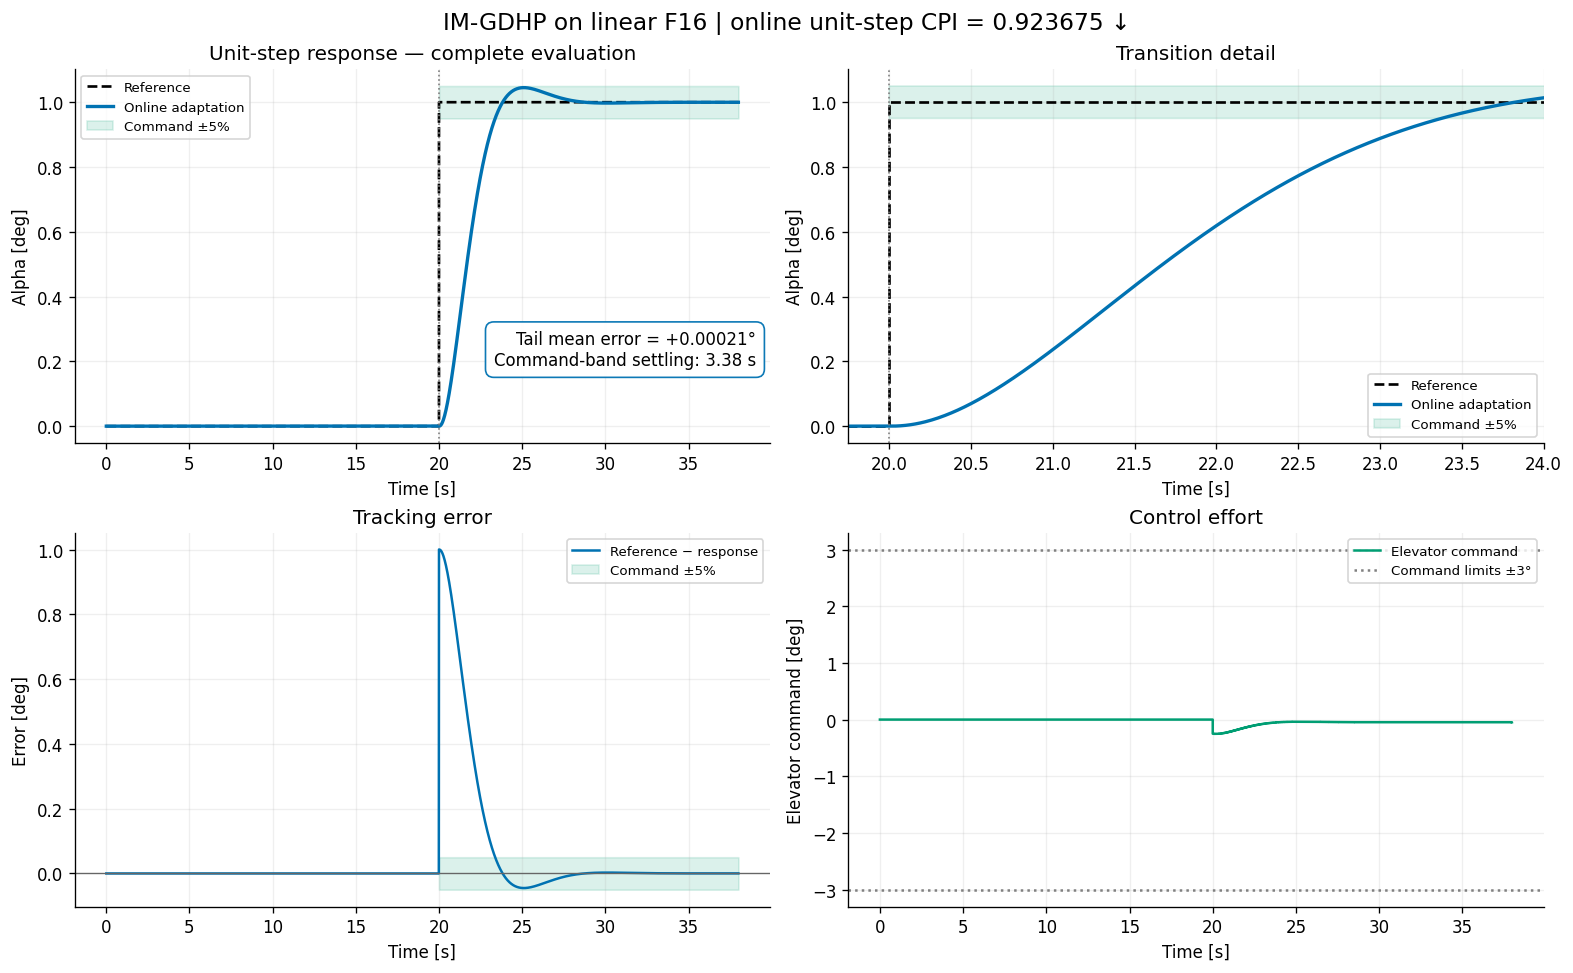

In [8]:
t_plot = np.arange(1, len(y) + 1) * DT
command_time = np.arange(len(u)) * DT
commanded_alpha = np.rad2deg(EVALUATION_REFERENCE[0, 1:len(y) + 1])
measured_alpha = np.rad2deg(y[:, 0])
tracking_error_deg = commanded_alpha - measured_alpha
band_deg = 0.05 * abs(STEP_AMPLITUDE_DEG)
post_step = t_plot >= STEP_TIME

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax in axes[0]:
    ax.step(t_plot, commanded_alpha, where="post", color="black", ls="--", lw=1.6, label="Reference")
    ax.plot(t_plot, measured_alpha, color="#0072B2", lw=2, label="Online adaptation")
    ax.fill_between(t_plot, commanded_alpha - band_deg, commanded_alpha + band_deg,
                    where=post_step, color="#009E73", alpha=0.14, label="Command ±5%")
    ax.axvline(STEP_TIME, color="0.5", ls=":", lw=1)
    ax.set(xlabel="Time [s]", ylabel="Alpha [deg]")
axes[0, 0].set_title("Unit-step response — complete evaluation")
axes[0, 1].set(title="Transition detail", xlim=(max(0, STEP_TIME - 0.25), STEP_TIME + 4.0))
axes[0, 0].annotate(
    f"Tail mean error = {static_deg:+.5f}°\nCommand-band settling: "
    + ("not reached" if online_step["command_settling_time"] is None
       else f"{online_step['command_settling_time']:.2f} s"),
    xy=(0.98, 0.25), xycoords="axes fraction", ha="right", va="center",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#0072B2", alpha=0.95),
)
axes[1, 0].plot(t_plot, tracking_error_deg, color="#0072B2", label="Reference − response")
axes[1, 0].fill_between(t_plot, -band_deg, band_deg, where=post_step,
                        color="#009E73", alpha=0.14, label="Command ±5%")
axes[1, 0].axhline(0, color="0.4", lw=0.8)
axes[1, 0].set(title="Tracking error", xlabel="Time [s]", ylabel="Error [deg]")
axes[1, 1].step(command_time, u[:, 0], where="post", color="#009E73", label="Elevator command")
axes[1, 1].axhline(cfg.u_max, color="0.5", ls=":", label=f"Command limits ±{cfg.u_max:g}°")
axes[1, 1].axhline(-cfg.u_max, color="0.5", ls=":")
axes[1, 1].set(title="Control effort", xlabel="Time [s]", ylabel="Elevator command [deg]")
for ax in axes.ravel():
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc="best")
fig.suptitle(
    f"IM-GDHP on linear F16 | online unit-step CPI = {online_step['performance_index']:.6f} ↓",
    fontsize=14,
)
plt.show()


### 5.4. Other amplitudes and late-time accuracy

Assess **0.5°, 2° and −1°**, plus a longer unit step, with the command always starting at **20 s**. These rollouts last **60 s**. The table includes the earlier 38-second prefix as well: increasing the horizon does not erase the earlier error.

For each amplitude, report both the last-10% mean error and its peak-to-peak variation. The final-5-second maximum absolute error tests whether a small mean hides oscillations. The stricter late-time target is **0.1% of the commanded amplitude**, in addition to the original 1% short-run target. CPI values from different horizons or amplitudes are not directly ranked.


,Step [deg],Duration [s],CPI ↓,Command overshoot [%],Command settling [s],Static error [deg],IAE [rad·s]
Experiment,,,,,,,
Primary,1.0,38.0,0.923675,4.502054,3.380,0.000212,0.032943
Larger command,2.0,60.0,0.550822,2.419444,3.550,0.000872,0.069075
Long adaptation,1.0,60.0,0.920155,4.502054,3.380,0.000022,0.032972
Smaller command,0.5,60.0,1.033652,5.123751,5.360,-0.000050,0.016666
Negative command,-1.0,60.0,0.922258,4.512865,3.380,-0.000020,0.032971


,Step [deg],38 s tail error [deg],60 s tail error [deg],60 s tail peak-to-peak [deg],Final 5 s max error [deg],Late accuracy ≤0.1%
Experiment,,,,,,
Larger command,2.0,0.010638,0.000872,0.000630,0.001086,PASS
Long adaptation,1.0,0.000212,0.000022,0.000017,0.000028,PASS
Smaller command,0.5,-0.000650,-0.000050,0.000036,0.000062,PASS
Negative command,-1.0,-0.000186,-0.000020,0.000012,0.000024,PASS


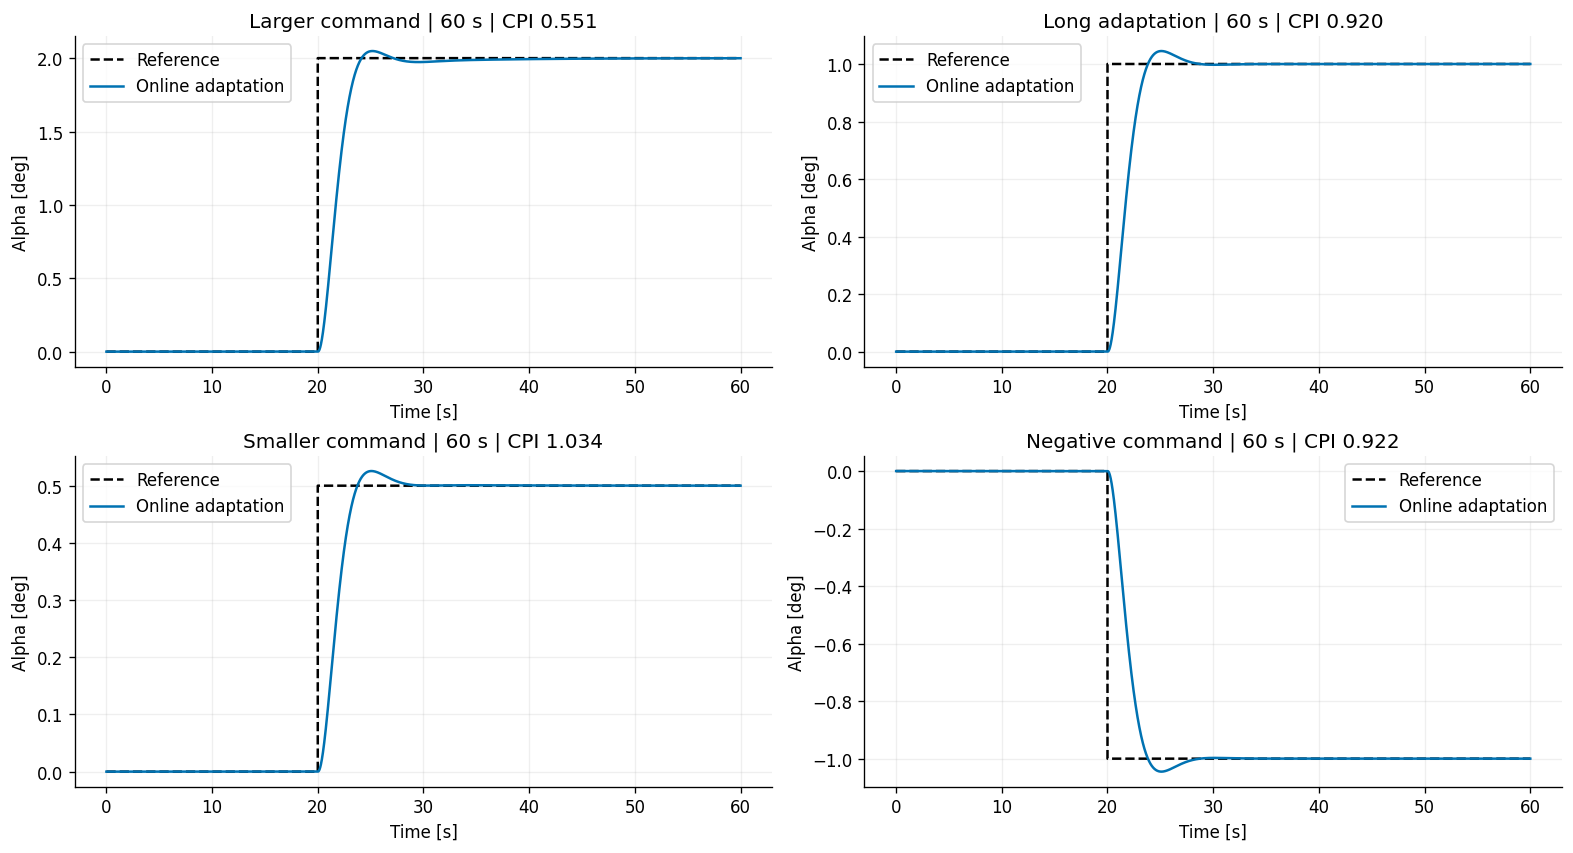

In [9]:
step_cases = [("Primary", STEP_AMPLITUDE_DEG, EVALUATION_DURATION, online_step)]
additional_step_responses = []
late_accuracy_rows = []
for name, amplitude_deg, duration in (("Larger command", 2.0, 60.0),
                                      ("Long adaptation", 1.0, 60.0),
                                      ("Smaller command", 0.5, 60.0),
                                      ("Negative command", -1.0, 60.0)):
    reference = step_reference(round(duration / DT), amplitude_deg)
    _, response, _ = run_episode(copy.deepcopy(agent), reference, learning=True)
    metrics = step_metrics(reference, response)
    step_cases.append((name, amplitude_deg, duration, metrics))
    prefix_samples = round(EVALUATION_DURATION / DT)
    prefix = step_metrics(reference[:, :prefix_samples], response[:prefix_samples - 1])
    late_error = np.rad2deg(reference[0, -500:] - response[-500:, 0].astype(float))
    late_max = float(np.max(np.abs(late_error)))
    late_accuracy_rows.append({
        "Experiment": name, "Step [deg]": amplitude_deg,
        "38 s tail error [deg]": np.rad2deg(prefix["tail_static_error"]),
        "60 s tail error [deg]": np.rad2deg(metrics["tail_static_error"]),
        "60 s tail peak-to-peak [deg]": np.rad2deg(metrics["tail_peak_to_peak"]),
        "Final 5 s max error [deg]": late_max,
        "Late accuracy ≤0.1%": "PASS" if late_max <= 0.001 * abs(amplitude_deg) else "FAIL",
    })
    additional_step_responses.append((name, duration, reference, response, metrics))

additional_step_table = pd.DataFrame([
    {
        "Experiment": name,
        "Step [deg]": amplitude,
        "Duration [s]": duration,
        "CPI ↓": metrics["performance_index"],
        "Command overshoot [%]": metrics["command_overshoot"],
        "Command settling [s]": ("Not reached" if metrics["command_settling_time"] is None
                                 else f"{metrics['command_settling_time']:.3f}"),
        "Static error [deg]": np.rad2deg(metrics["tail_static_error"]),
        "IAE [rad·s]": metrics["iae"],
    }
    for name, amplitude, duration, metrics in step_cases
]).set_index("Experiment")
display(additional_step_table.round(6))
display(pd.DataFrame(late_accuracy_rows).set_index("Experiment").round(7))

fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
axes = axes.ravel()
for ax, (name, duration, reference, response, metrics) in zip(axes, additional_step_responses):
    time = np.arange(1, len(response) + 1) * DT
    ax.step(time, np.rad2deg(reference[0, 1:len(response) + 1]), where="post",
            color="black", ls="--", label="Reference")
    ax.plot(time, np.rad2deg(response[:, 0]), color="#0072B2", label="Online adaptation")
    ax.set(title=f"{name} | {duration:g} s | CPI {metrics['performance_index']:.3f}",
           xlabel="Time [s]", ylabel="Alpha [deg]")
    ax.grid(alpha=0.2)
    ax.legend()
plt.show()


### 5.4.1. 500 seconds with continuing adaptation

The unit step still starts at 20 s. Actor, critic and identifier continue updating for the entire 500-second run. Positive learning rates are printed below. Inspect the full error trace and settling within the command ±1% band; a small final mean alone does not establish convergence.

This is a **numerical stress test of the fixed linear model**, not validation of a long nonlinear flight. Nonzero alpha produces nonzero pitch rate in this reduced plant, so pitch accumulates far outside a small-perturbation interpretation. This CPI has a different horizon from the primary assessment.


500 s final-10% mean error: +0.00000887 deg
500 s final-10% peak-to-peak response: 0.00000000 deg
500 s CPI (separate horizon): 0.927028
Settling within command ±1% over the whole 500 s: 7.54 s after step
Final learning rates: 0.019916313603912175 1e-05
Accumulated maximum |pitch angle|: 284.2 deg — outside a small-perturbation flight interpretation


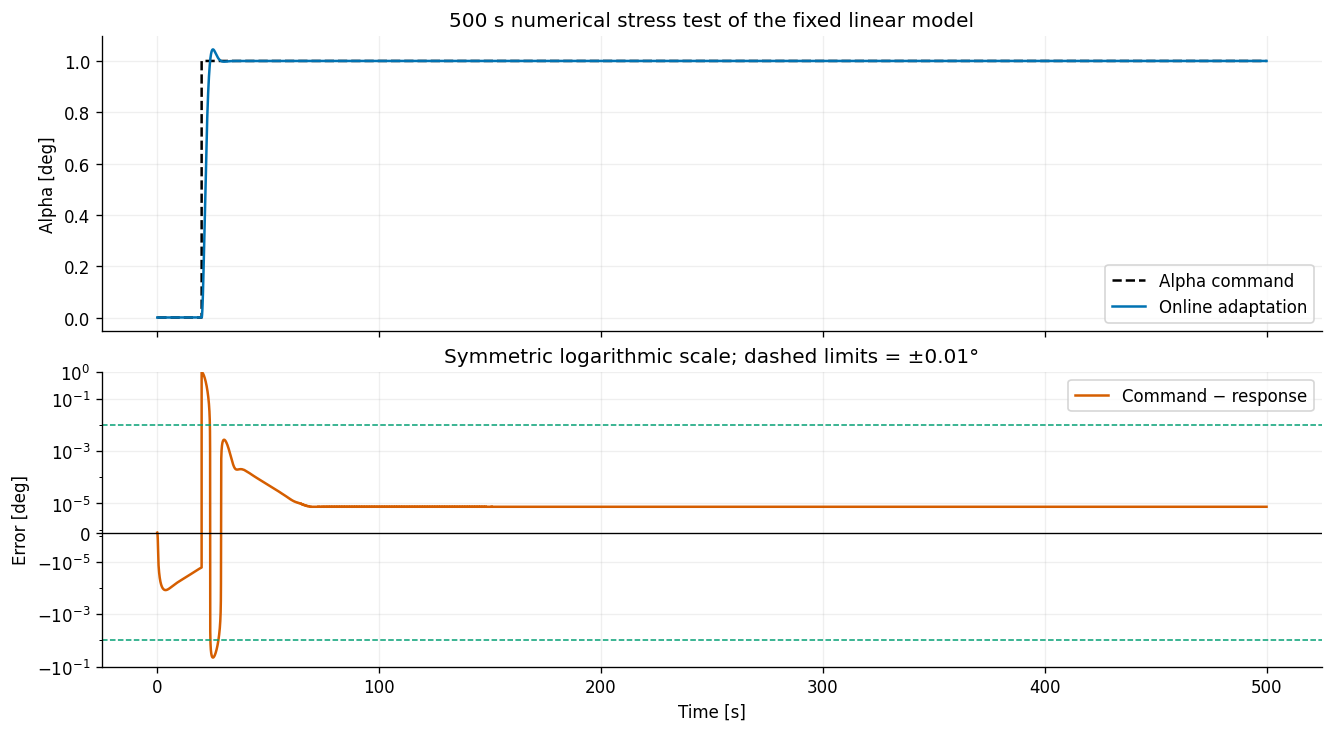

In [10]:
long_reference = step_reference(round(500.0 / DT))
long_agent = copy.deepcopy(agent)
long_metrics, long_y, long_u = run_episode(long_agent, long_reference, learning=True)
long_step = step_metrics(long_reference, long_y)
long_one_percent = benchmark.benchmarking_step_response(
    long_reference[0, 1:], long_y[:, 0], 0.0, DT, tolerance=0.01
)
print(f"500 s final-10% mean error: {np.rad2deg(long_step['tail_static_error']):+.8f} deg")
print(f"500 s final-10% peak-to-peak response: {np.rad2deg(long_step['tail_peak_to_peak']):.8f} deg")
print(f"500 s CPI (separate horizon): {long_step['performance_index']:.6f}")
print("Settling within command ±1% over the whole 500 s:", long_one_percent["command_settling_time"], "s after step")
print("Final learning rates:", long_agent.actor_opt.param_groups[0]["lr"],
      long_agent.critic_opt.param_groups[0]["lr"])
print(f"Accumulated maximum |pitch angle|: {long_metrics['peak_theta_deg']:.1f} deg — outside a small-perturbation flight interpretation")

long_time = np.arange(1, len(long_y) + 1) * DT
long_error = np.rad2deg(long_reference[0, 1:] - long_y[:, 0].astype(float))
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
axes[0].step(long_time, np.rad2deg(long_reference[0, 1:]), where="post", color="black", ls="--", label="Alpha command")
axes[0].plot(long_time, np.rad2deg(long_y[:, 0]), color="#0072B2", label="Online adaptation")
axes[0].set(ylabel="Alpha [deg]", title="500 s numerical stress test of the fixed linear model")
axes[0].legend()
axes[1].plot(long_time, long_error, color="#D55E00", label="Command − response")
axes[1].axhline(0, color="black", lw=0.8)
for level in (-0.01, 0.01):
    axes[1].axhline(level, color="#009E73", ls="--", lw=0.9)
axes[1].set_yscale("symlog", linthresh=1e-5)
axes[1].set_yticks([-0.1, -0.001, -1e-5, 0, 1e-5, 0.001, 0.1, 1.0])
axes[1].set(xlabel="Time [s]", ylabel="Error [deg]", title="Symmetric logarithmic scale; dashed limits = ±0.01°")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.2)
plt.show()


### 5.5. Secondary sinusoidal tracking diagnostic

The reference still commands alpha only. A 2° sine with a 4-second period is a more demanding tracking task than the step tests. **The current step-tuned policy does not track this fast sine accurately:** the executed 12-second diagnostic has RMSE approximately **1.685°**. This limitation is retained rather than replacing the command with an easier signal.

Sinusoidal RMSE does not replace the step-response CPI. The independent seed checks below repeat the updated two-stage training; their current results supersede the failures of earlier configurations.


In [11]:
t_diagnostic = np.arange(1200) * DT
sine_reference = np.deg2rad(2 * np.sin(2 * np.pi * t_diagnostic / 4))[None, :]
try:
    sine_metrics, _, _ = run_episode(copy.deepcopy(agent), sine_reference, learning=True)
    print("Sinusoidal tracking diagnostic:", sine_metrics)
except (RuntimeError, ValueError, FloatingPointError) as exc:
    print("Sinusoidal tracking FAILED:", exc)


Sinusoidal tracking diagnostic: {'rmse_deg': 1.684739366698682, 'mae_deg': 1.5034454190848783, 'peak_alpha_deg': 0.9151015281677246, 'peak_rate_deg_s': 1.0946741104125977, 'peak_command_deg': 0.637323260307312, 'saturation_fraction': 0.0, 'samples': 1199, 'peak_theta_deg': 1.609705637521572}


### 5.6. Uncommanded pitch rate and the linear-model limitation

There is **no `q_ref`** in this experiment. Pitch rate is the resulting motion, plotted below without a target. The angle-of-attack controller does not regulate pitch angle, altitude or speed. A prolonged nonzero pitch rate accumulates a pitch-angle change, so long runs of a fixed linearization are numerical stress tests rather than evidence of physically credible sustained flight. The nonlinear identification example below does not resolve this control limitation.


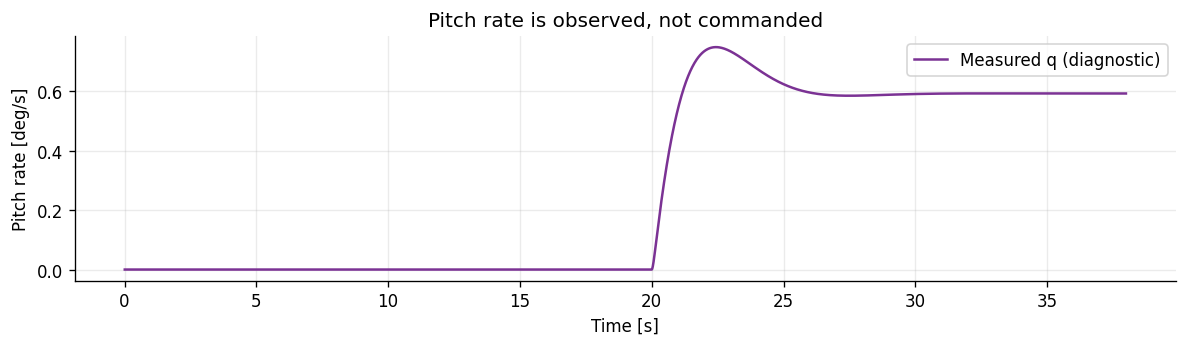

Primary maximum |pitch angle| in the linear model: 10.733 deg
Primary peak elevator command: 0.252 deg
Primary command saturation fraction: 0.000000


In [12]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(1, len(y) + 1) * DT, np.rad2deg(y[:, 1]), color="#7B3294", label="Measured q (diagnostic)")
ax.set(xlabel="Time [s]", ylabel="Pitch rate [deg/s]", title="Pitch rate is observed, not commanded")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Primary maximum |pitch angle| in the linear model: {online_metrics['peak_theta_deg']:.3f} deg")
print(f"Primary peak elevator command: {online_metrics['peak_command_deg']:.3f} deg")
print(f"Primary command saturation fraction: {online_metrics['saturation_fraction']:.6f}")


### 5.7. Independent training seeds

Repeat both training stages from scratch with seeds 1 and 2. Each warm start is followed by the **same** feedback/adaptation-sensitivity targets and zero-reference episode. The resulting actor learning rates can differ because the learned gradients differ; this is why a single raw SGD rate did not transfer reliably between initializations.

Every seed is evaluated on **0.5°, ±1° and 2°**, with 60-second total duration and continuing adaptation. The table retains any failed run. Three successful seeds are a reproducibility check, not a Monte Carlo stability proof.


In [13]:
seed_results = []
for trial_seed in (0, 1, 2):
    phase = "training"
    completed = 0
    try:
        if trial_seed == 0:
            trial = copy.deepcopy(agent)
            completed = NUM_EPISODES
            tuning = online_tuning
        else:
            trial = IMGDHPAgent(
                n_obs=2, n_action=1, reference_size=1, tracking_indices=[0],
                config=replace(cfg, seed=trial_seed),
            )
            for _ in range(NUM_EPISODES):
                run_episode(trial, REFERENCE, learning=True, noise=0.1)
                completed += 1
            phase = "sensitivity tuning and zero-reference training"
            tuning = prepare_online_learning(trial)
        phase = "step evaluation"
        for amplitude in (1.0, -1.0, 0.5, 2.0):
            reference = step_reference(round(60.0 / DT), amplitude)
            _, trial_y, _ = run_episode(copy.deepcopy(trial), reference, learning=True)
            metrics = step_metrics(reference, trial_y)
            late = np.rad2deg(reference[0, -500:] - trial_y[-500:, 0].astype(float))
            max_error = float(np.max(np.abs(late)))
            seed_results.append({
                "Seed": trial_seed, "Step [deg]": amplitude, "Outcome": "Completed",
                "Actor learning rate": tuning["Online actor learning rate"],
                "CPI": metrics["performance_index"],
                "Tail mean error [deg]": np.rad2deg(metrics["tail_static_error"]),
                "Final 5 s max error [deg]": max_error,
                "Command overshoot [%]": metrics["command_overshoot"],
                "Late accuracy ≤0.1%": "PASS" if max_error <= 0.001 * abs(amplitude) else "FAIL",
            })
    except (RuntimeError, ValueError, FloatingPointError) as exc:
        seed_results.append({"Seed": trial_seed, "Outcome": f"FAILED during {phase} after {completed} episodes: {exc}"})
display(pd.DataFrame(seed_results).set_index(["Seed", "Step [deg]"]).round(7))


Outcome  Actor learning rate       CPI  \
Seed Step [deg]                                             
0     1.0        Completed             0.019916  0.920155   
     -1.0        Completed             0.019916  0.922258   
      0.5        Completed             0.019916  1.033652   
      2.0        Completed             0.019916  0.550822   
1     1.0        Completed             2.960771  0.934475   
     -1.0        Completed             2.960771  0.924538   
      0.5        Completed             2.960771  1.037299   
      2.0        Completed             2.960771  0.626433   
2     1.0        Completed             0.000069  1.013699   
     -1.0        Completed             0.000069  1.009829   
      0.5        Completed             0.000069  1.061544   
      2.0        Completed             0.000069  0.828256   

                 Tail mean error [deg]  Final 5 s max error [deg]  \
Seed Step [deg]                                                     
0     1.0                     0.000022                   0.000028   
     -1.0                    -0.000020                   0.000024   
      0.5                    -0.000050                   0.000062   
      2.0                     0.000872                   0.001086   
1     1.0                    -0.000054                   0.000067   
     -1.0                     0.000049                   0.000061   
      0.5                    -0.000060                   0.000075   
      2.0                     0.000371                   0.000460   
2     1.0                    -0.000070                   0.000086   
     -1.0                     0.000066                   0.000084   
      0.5                    -0.000060                   0.000074   
      2.0                     0.000268                   0.000334   

                 Command overshoot [%] Late accuracy ≤0.1%  
Seed Step [deg]                                             
0     1.0                     4.502054                PASS  
     -1.0                     4.512865                PASS  
      0.5                     5.123751                PASS  
      2.0                     2.419444                PASS  
1     1.0                     4.572512                PASS  
     -1.0                     4.522790                PASS  
      0.5                     5.141595                PASS  
      2.0                     2.851294                PASS  
2     1.0                     4.971929                PASS  
     -1.0                     4.952591                PASS  
      0.5                     5.262831                PASS  
      2.0                     3.909055                PASS

### 5.8. Command sequence and a delayed step

Use a **single continuously adapting agent** for `0 → 1 → 0 → −1 → 0.5 → −2 → 0` degrees. It is reset only at the beginning of the full rollout. Report the final five seconds of every plateau, including returns to zero.

A separate 240-second rollout holds zero until **200 s**, then commands 1°. The learned policy is not told this time through a gain schedule; it receives the same reference API as in every other assessment. These are numerical linear-model checks, with the pitch limitations discussed above.


,Start [s],End [s],Reference [deg],Final 5 s mean error [deg],Final 5 s max error [deg],Final 5 s peak-to-peak [deg]
0,0.0,20.0,0.0,-0.000022,0.000030,0.000014
1,20.0,60.0,1.0,0.000021,0.000028,0.000013
2,60.0,100.0,0.0,-0.000046,0.000061,0.000027
3,100.0,140.0,-1.0,-0.000022,0.000029,0.000012
4,140.0,180.0,0.5,0.000298,0.000396,0.000179
5,180.0,220.0,-2.0,-0.001921,0.002537,0.001124
6,220.0,260.0,0.0,0.000910,0.001206,0.000539


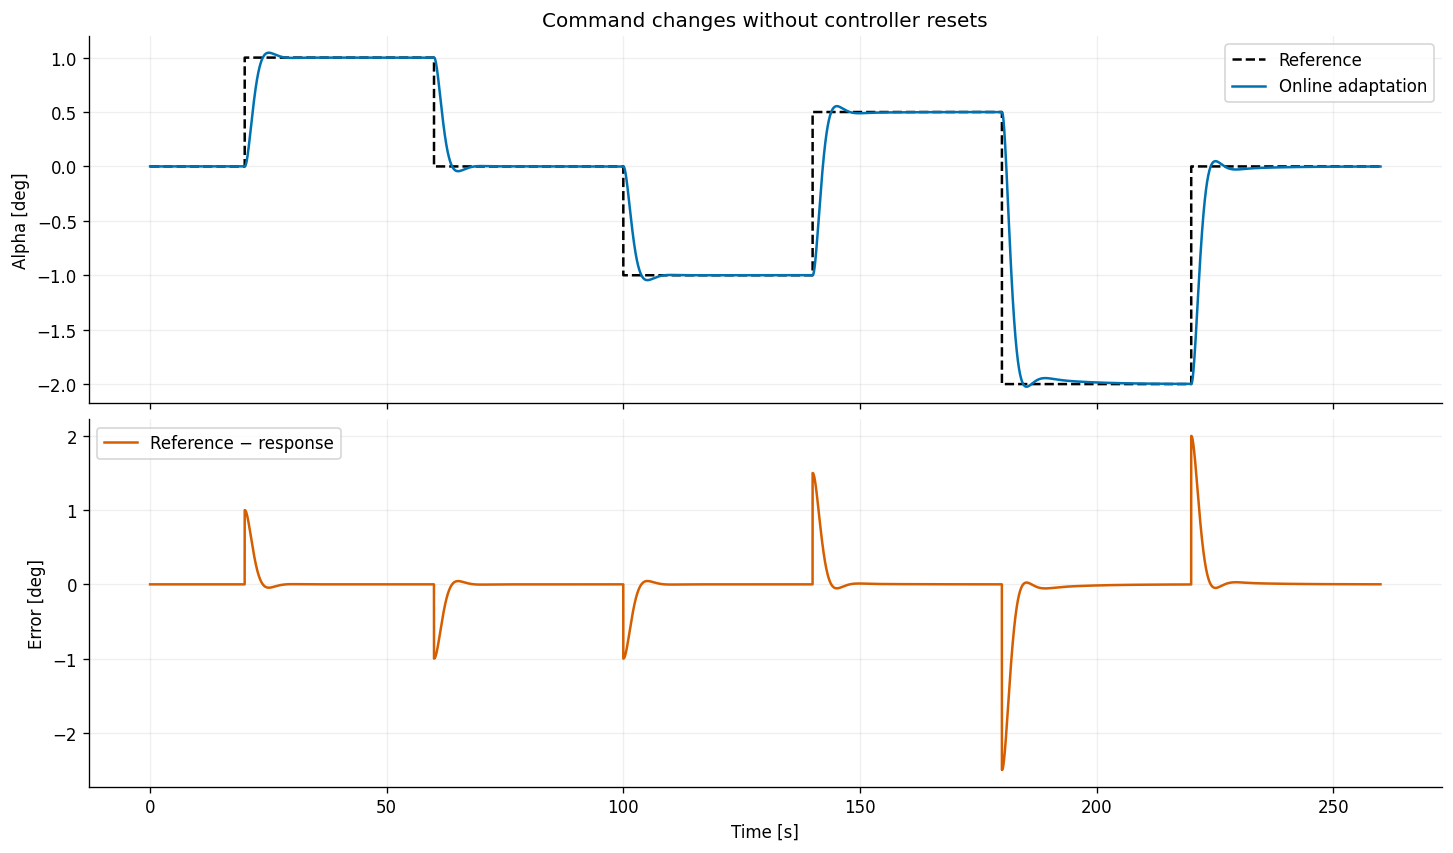

Step at 200 s, tail mean error [deg]: 8.747915189835463e-05
Step at 200 s, command overshoot [%]: 4.500602968555123


In [14]:
sequence_levels = [(0.0, 0.0), (20.0, 1.0), (60.0, 0.0),
                   (100.0, -1.0), (140.0, 0.5), (180.0, -2.0), (220.0, 0.0)]
sequence_reference = np.zeros((1, round(260.0 / DT)))
for start, amplitude in sequence_levels:
    sequence_reference[:, round(start / DT):] = np.deg2rad(amplitude)
sequence_metrics, sequence_y, sequence_u = run_episode(
    copy.deepcopy(agent), sequence_reference, learning=True
)
sequence_time = np.arange(1, len(sequence_y) + 1) * DT
sequence_error = np.rad2deg(sequence_reference[0, 1:] - sequence_y[:, 0].astype(float))
sequence_rows = []
ends = [start for start, _ in sequence_levels[1:]] + [260.0]
for (start, amplitude), end in zip(sequence_levels, ends):
    mask = (sequence_time >= end - 5.0) & (sequence_time < end)
    tail = sequence_error[mask]
    sequence_rows.append({"Start [s]": start, "End [s]": end, "Reference [deg]": amplitude,
                          "Final 5 s mean error [deg]": float(tail.mean()),
                          "Final 5 s max error [deg]": float(np.abs(tail).max()),
                          "Final 5 s peak-to-peak [deg]": float(np.ptp(tail))})
display(pd.DataFrame(sequence_rows).round(7))
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].step(sequence_time, np.rad2deg(sequence_reference[0, 1:]), where="post",
             color="black", ls="--", label="Reference")
axes[0].plot(sequence_time, np.rad2deg(sequence_y[:, 0]), color="#0072B2", label="Online adaptation")
axes[0].set(ylabel="Alpha [deg]", title="Command changes without controller resets")
axes[1].plot(sequence_time, sequence_error, color="#D55E00", label="Reference − response")
axes[1].set(xlabel="Time [s]", ylabel="Error [deg]")
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend()
plt.show()
late_reference = np.zeros((1, round(240.0 / DT)))
late_reference[:, round(200.0 / DT):] = np.deg2rad(1.0)
_, late_y, _ = run_episode(copy.deepcopy(agent), late_reference, learning=True)
late_step_metrics = step_metrics(late_reference, late_y)
print("Step at 200 s, tail mean error [deg]:", np.rad2deg(late_step_metrics["tail_static_error"]))
print("Step at 200 s, command overshoot [%]:", late_step_metrics["command_overshoot"])


## 6. Nonlinear F16: prediction before measurement assimilation

This separate experiment applies a small multisine around the existing trim bias. It evaluates the incremental **identifier**, not the trained linear policy. Predictions are made **before** the sample is used for the RLS update; otherwise the displayed error would be an in-sample fit. The four-increment window uses only past measurements. Report post-warmup error separately from startup.

In [15]:
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal import initial_state

N_ID = 2000
x0 = initial_state.reshape(-1)
nonlin_env = gym.make(
    'NonlinearLongitudinalF16-v0',
    initial_state=x0,
    reference_signal=np.zeros((1, N_ID)),
    number_time_steps=N_ID,
    control_bias=-4.45,  # F-16 trim elevator
    dt=DT,
).unwrapped

rls_nl = IncrementalModelRLS(n_y=2, n_u=1, forgetting=0.999, cov_init=1e4, seed=0, history_length=4)
rng = np.random.default_rng(0)
obs, _ = nonlin_env.reset()
obs = np.asarray(obs).reshape(-1).astype(np.float64)
y_hist = [obs.copy(), obs.copy()]
u_hist = [np.zeros(1)]
y_true_log, y_pred_log = [], []

for t in range(N_ID - 1):
    # Multi-sine persistently-exciting input (small amplitude around trim)
    u_t = np.array([
        0.5*np.sin(2*np.pi*0.3*t*DT)
        + 0.3*np.sin(2*np.pi*0.9*t*DT)
        + 0.2*np.sin(2*np.pi*1.7*t*DT)
        + 0.1*rng.normal()
    ])
    obs_next, _, done, truncated, _ = nonlin_env.step(u_t)
    obs_next = np.asarray(obs_next).reshape(-1).astype(np.float64)
    y_hist.append(obs_next); u_hist.append(u_t)
    if t >= 1:
        y_pred = rls_nl.predict_next(
            y_curr=y_hist[-2], y_prev=y_hist[-3],
            u_curr=u_hist[-1], u_prev=u_hist[-2],
        )
        rls_nl.update(y_hist[-3], y_hist[-2], y_hist[-1], u_hist[-2], u_hist[-1])
        y_true_log.append(y_hist[-1].copy())
        y_pred_log.append(y_pred.copy())
    if done or truncated:
        break

y_true_arr = np.array(y_true_log)
y_pred_arr = np.array(y_pred_log)
nonlin_env.close()
pred_err = (y_true_arr - y_pred_arr)[200:]
print(f'Final identification after {rls_nl.num_updates} RLS updates:')
print(f'  A =\n{np.round(rls_nl.A, 4)}')
print(f'  B = {rls_nl.B.ravel()}')
print(f'  post-warmup prior-prediction RMSE (alpha) = {np.sqrt(np.mean(pred_err[:,0]**2)):.2e} rad')
print(f'  post-warmup prior-prediction RMSE (q)     = {np.sqrt(np.mean(pred_err[:,1]**2)):.2e} rad/s')

Final identification after 1995 RLS updates:
  A =
[[ 0.2256  0.0038  0.2268  0.0077  0.2285  0.0092  0.2288  0.0123]
 [-0.0057  0.492  -0.0105  0.3219 -0.0158  0.1511 -0.0168  0.0134]]
  B = [ 1.03855954e-05  1.67555421e-05  1.69800303e-05  1.09455050e-05
 -5.44424181e-05 -4.62755265e-05 -1.18733239e-04 -1.24699348e-04]
  post-warmup prior-prediction RMSE (alpha) = 5.31e-05 rad
  post-warmup prior-prediction RMSE (q)     = 1.09e-04 rad/s


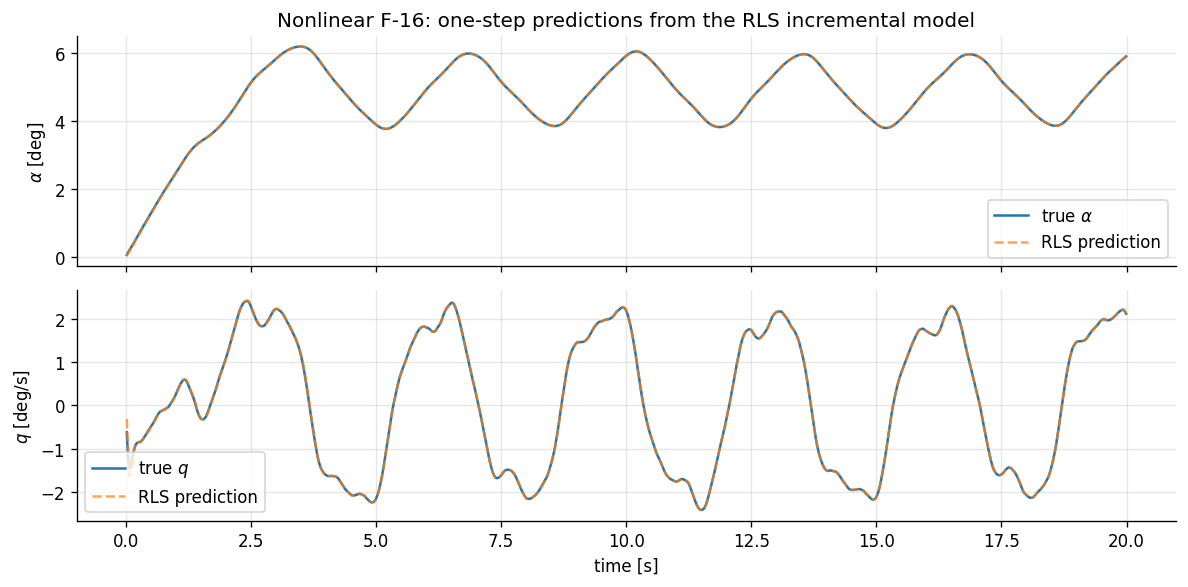

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
t_id = (np.arange(len(y_true_arr)) + 2) * DT
axes[0].plot(t_id, np.degrees(y_true_arr[:, 0]), label='true $\\alpha$')
axes[0].plot(t_id, np.degrees(y_pred_arr[:, 0]), '--', alpha=0.7, label='RLS prediction')
axes[0].set_ylabel('$\\alpha$ [deg]'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Nonlinear F-16: one-step predictions from the RLS incremental model')
axes[1].plot(t_id, np.degrees(y_true_arr[:, 1]), label='true $q$')
axes[1].plot(t_id, np.degrees(y_pred_arr[:, 1]), '--', alpha=0.7, label='RLS prediction')
axes[1].set_ylabel('$q$ [deg/s]'); axes[1].set_xlabel('time [s]'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Saving and interpreting the result

`agent.save("checkpoints", save_gradients=True)` saves the fully trained seed-0 candidate, its known-reference mode, transformed actor input weights, optimizer state, identifier and noise generator. Restore it with `IMGDHPAgent.from_pretrained(path, load_gradients=True)`. A new independent rollout calls `reset()`; exact continuation additionally requires the environment state and time index.

The primary 38-second comparison uses the original horizon. The 60-second tables additionally measure settled accuracy, including tail variation and worst tail error. The sequence and delayed-step tests keep one adapting controller through command changes; no parameters are reset at those changes.

The published actor/critic losses are retained. Known-reference identification and the two-stage sensitivity-based tuning are explicit additions to the experimental protocol. They are not claimed as a reproduction of the paper's experiment or as a general proof of stability. The fast-sinusoid diagnostic and the distinction between linear tracking and nonlinear identification remain visible.
